# Karachi AQI EDA with Open-Meteo

This notebook follows the practical EDA rhythm from Aurelien Geron's end-to-end ML project notebook: get the data, take a quick look, create a simple holdout split, visualize patterns, inspect correlations, and sketch useful features.

## Setup

In [1]:
from datetime import date, timedelta
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
    

sys.path.append(str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv

from aqi_predictor.data.sources import Location, fetch_open_meteo_data

load_dotenv(PROJECT_ROOT / ".env")

pd.set_option("display.max_columns", 80)
sns.set_theme(style="whitegrid")

## Get the Data

Open-Meteo does not require an API key for this use case. The location comes from `.env`.

In [2]:
city = os.getenv("AQI_CITY", "Karachi")
latitude = float(os.getenv("AQI_LATITUDE", "24.8608"))
longitude = float(os.getenv("AQI_LONGITUDE", "67.0104"))

location = Location(latitude=latitude, longitude=longitude, name=city)
location

Location(latitude=24.8608, longitude=67.0104, name='Karachi')

In [3]:
end_date = date.today() - timedelta(days=5)
start_date = end_date - timedelta(days=365 * 2)

raw_data_path = PROJECT_ROOT / "data" / "raw" / f"open_meteo_{city.lower()}_{start_date}_{end_date}.csv"

if raw_data_path.exists():
    aqi = pd.read_csv(raw_data_path, parse_dates=["time"])
else:
    aqi = fetch_open_meteo_data(location, start_date=start_date, end_date=end_date)
    raw_data_path.parent.mkdir(parents=True, exist_ok=True)
    aqi.to_csv(raw_data_path, index=False)

aqi = aqi.sort_values("time").reset_index(drop=True)
aqi.head()

,time,temperature_2m,relative_humidity_2m,precipitation,pressure_msl,wind_speed_10m,wind_direction_10m,latitude,longitude,location_name,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,us_aqi
0,2024-08-08 00:00:00,27.9,82,0.0,1002.4,19.6,234,24.8608,67.0104,Karachi,71.9,22.6,192.0,11.9,3.8,40.0,71
1,2024-08-08 01:00:00,27.9,81,0.0,1002.1,20.1,237,24.8608,67.0104,Karachi,69.4,21.8,168.0,9.1,3.4,42.0,71
2,2024-08-08 02:00:00,27.9,81,0.0,1001.5,20.3,240,24.8608,67.0104,Karachi,65.2,21.2,150.0,7.0,3.2,44.0,71
3,2024-08-08 03:00:00,28.0,80,0.0,1001.5,20.2,248,24.8608,67.0104,Karachi,67.8,22.5,141.0,6.1,3.3,44.0,71
4,2024-08-08 04:00:00,27.9,81,0.0,1001.4,21.3,248,24.8608,67.0104,Karachi,61.2,21.8,137.0,5.9,3.5,43.0,72


## Take a Quick Look at the Data Structure

In [4]:
aqi.info()

<class 'pandas.DataFrame'>
RangeIndex: 17544 entries, 0 to 17543
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   time                  17544 non-null  datetime64[us]
 1   temperature_2m        17544 non-null  float64       
 2   relative_humidity_2m  17544 non-null  int64         
 3   precipitation         17544 non-null  float64       
 4   pressure_msl          17544 non-null  float64       
 5   wind_speed_10m        17544 non-null  float64       
 6   wind_direction_10m    17544 non-null  int64         
 7   latitude              17544 non-null  float64       
 8   longitude             17544 non-null  float64       
 9   location_name         17544 non-null  str           
 10  pm10                  17544 non-null  float64       
 11  pm2_5                 17544 non-null  float64       
 12  carbon_monoxide       17544 non-null  float64       
 13  nitrogen_dioxide      17544

In [5]:
aqi.describe()

,time,temperature_2m,relative_humidity_2m,precipitation,pressure_msl,wind_speed_10m,wind_direction_10m,latitude,longitude,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,us_aqi
count,17544,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,1.754400e+04,17544.0000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000
mean,2025-08-08 11:30:00,26.668873,64.903215,0.032051,1008.597315,11.583100,219.479822,2.486080e+01,67.0104,55.533744,28.154913,510.074954,20.201408,14.078580,70.919802,87.986092
min,2024-08-08 00:00:00,9.300000,5.000000,0.000000,993.600000,0.000000,1.000000,2.486080e+01,67.0104,3.700000,3.500000,46.000000,0.000000,2.600000,0.000000,41.000000
25%,2025-02-06 17:45:00,24.000000,51.000000,0.000000,1003.200000,7.800000,213.000000,2.486080e+01,67.0104,36.100000,19.500000,226.000000,7.400000,7.600000,44.000000,73.000000
50%,2025-08-08 11:30:00,27.600000,70.000000,0.000000,1008.500000,11.000000,248.000000,2.486080e+01,67.0104,48.500000,25.000000,336.000000,13.400000,12.400000,62.000000,82.000000
75%,2026-02-07 05:15:00,29.800000,82.000000,0.000000,1014.100000,14.800000,270.000000,2.486080e+01,67.0104,66.600000,33.400000,637.000000,26.700000,18.000000,93.000000,98.000000
max,2026-08-08 23:00:00,41.200000,100.000000,16.500000,1025.200000,46.600000,360.000000,2.486080e+01,67.0104,504.800000,108.700000,4515.000000,138.500000,65.400000,213.000000,173.000000
std,NaN,4.696434,21.306277,0.384529,6.605226,5.294519,90.815448,7.105630e-15,0.0000,32.258100,12.707015,446.847913,18.579966,8.622207,39.045607,21.952508


In [6]:
missing = aqi.isna().sum().sort_values(ascending=False)
missing[missing > 0]

Series([], dtype: int64)

In [7]:
aqi["us_aqi"].describe()

count    17544.000000
mean        87.986092
std         21.952508
min         41.000000
25%         73.000000
50%         82.000000
75%         98.000000
max        173.000000
Name: us_aqi, dtype: float64

## Create a Simple Time-Based Holdout Set

For time series data, avoid a random split. Keep the latest observations as a rough validation slice and use the earlier observations for exploration.

In [8]:
split_index = int(len(aqi) * 0.8)

train_set = aqi.iloc[:split_index].copy()
test_set = aqi.iloc[split_index:].copy()

len(train_set), len(test_set), train_set["time"].min(), train_set["time"].max(), test_set["time"].min(), test_set["time"].max()

(14035,
 3509,
 Timestamp('2024-08-08 00:00:00'),
 Timestamp('2026-03-15 18:00:00'),
 Timestamp('2026-03-15 19:00:00'),
 Timestamp('2026-08-08 23:00:00'))

## Discover and Visualize the Data

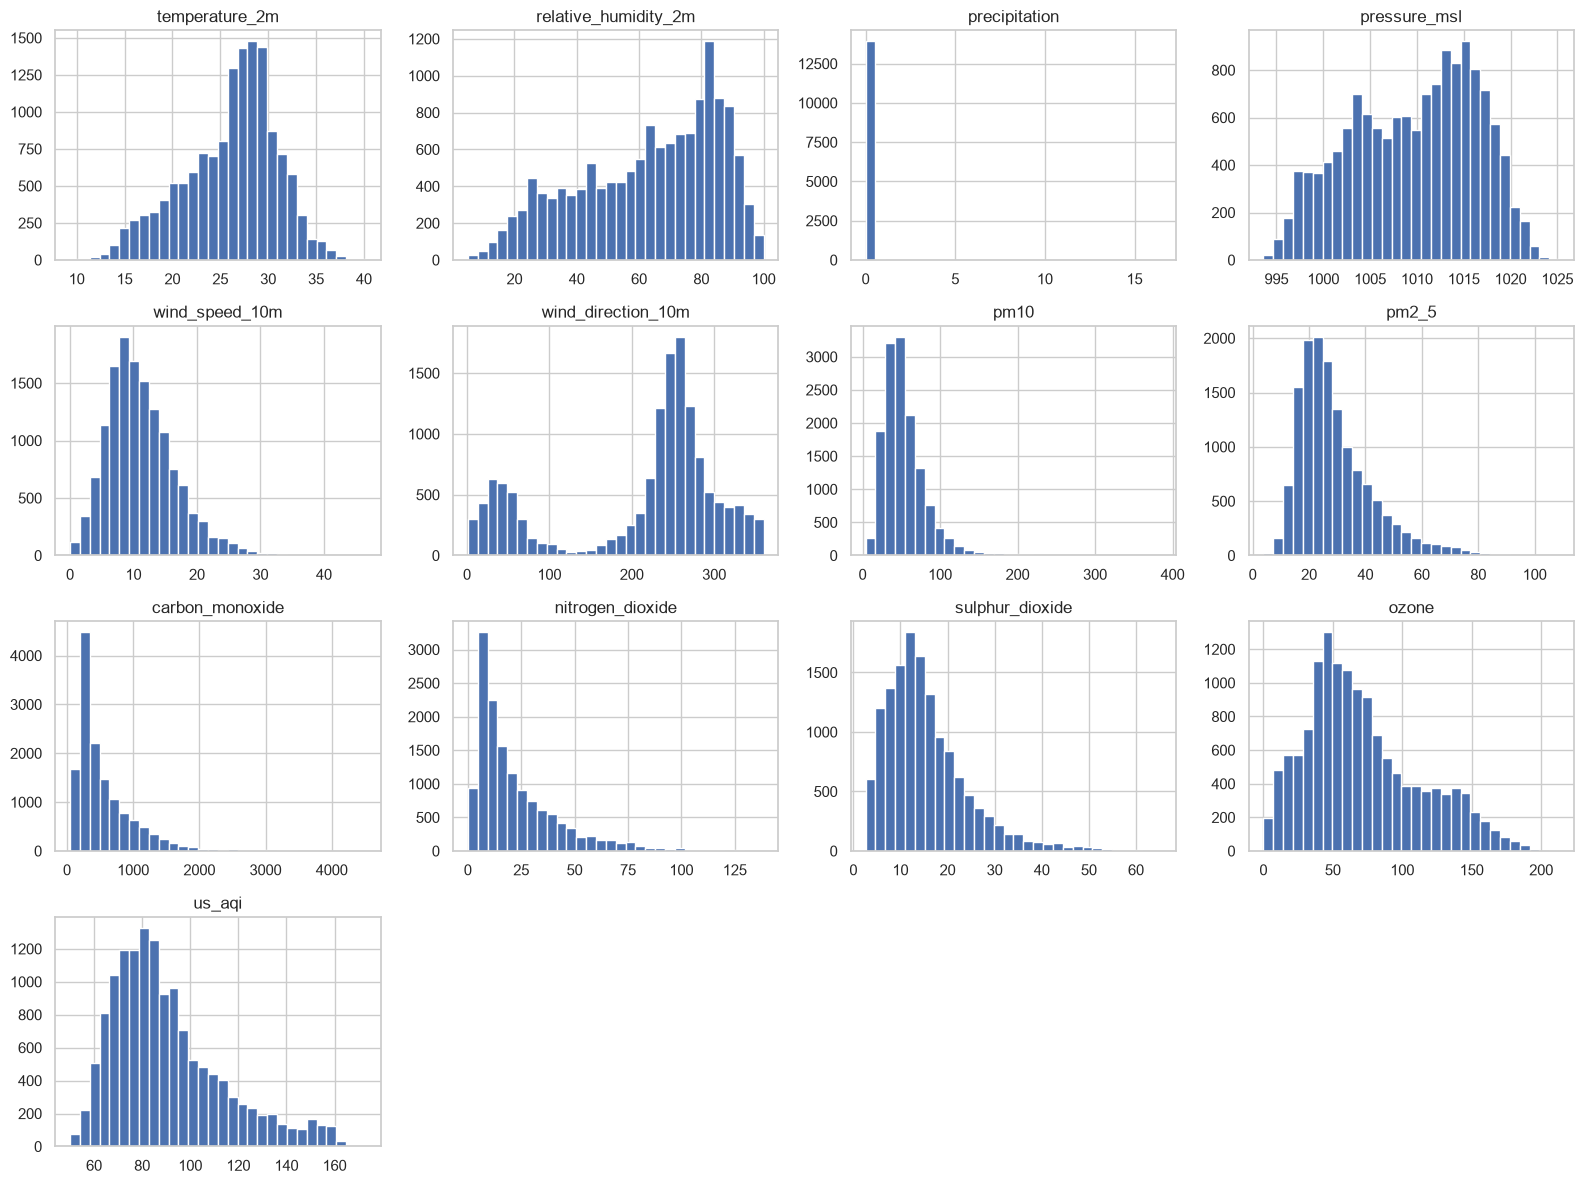

In [12]:
numeric_columns = train_set.select_dtypes(include="number").columns

# remove longitude and latitude from numeric columns
numeric_columns = numeric_columns.drop(["latitude", "longitude"])

train_set[numeric_columns].hist(bins=30, figsize=(16, 12))
plt.tight_layout();

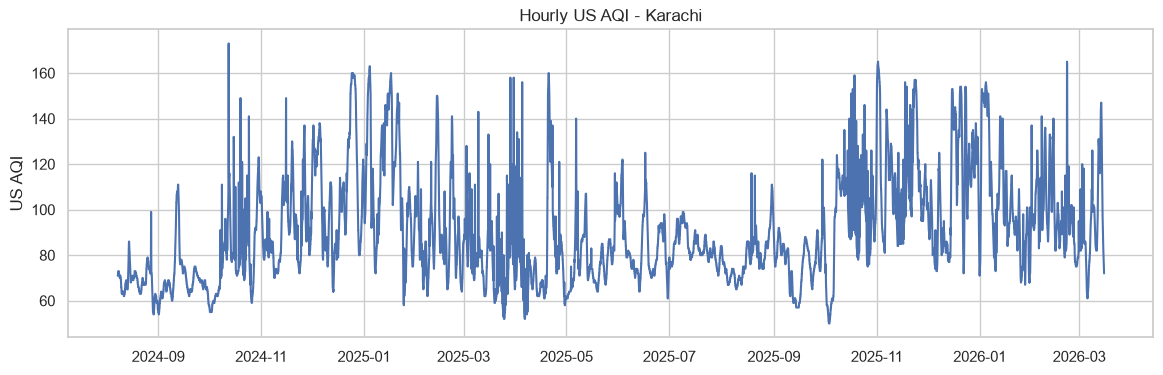

In [10]:
fig, ax = plt.subplots(figsize=(14, 4))
sns.lineplot(data=train_set, x="time", y="us_aqi", ax=ax)
ax.set_title(f"Hourly US AQI - {city}")
ax.set_xlabel("")
ax.set_ylabel("US AQI");

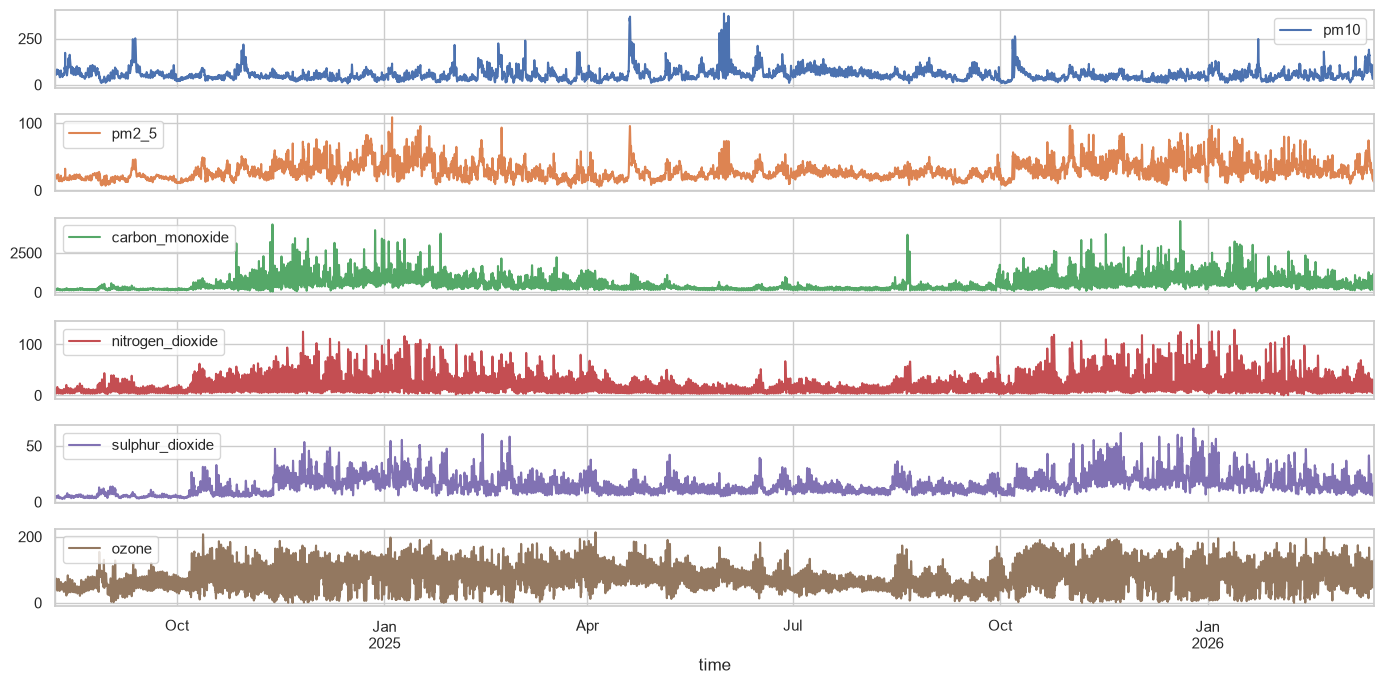

In [11]:
pollutant_columns = ["pm10", "pm2_5", "carbon_monoxide", "nitrogen_dioxide", "sulphur_dioxide", "ozone"]

train_set.set_index("time")[pollutant_columns].plot(figsize=(14, 7), subplots=True, sharex=True)
plt.tight_layout();

## Add Simple Time Features for EDA

In [ ]:
eda = train_set.copy()
eda = eda.drop(["latitude", "longitude"], axis=1)
eda["hour"] = eda["time"].dt.hour
eda["day_of_week"] = eda["time"].dt.day_name()
eda["month"] = eda["time"].dt.month
eda["aqi_change_1h"] = eda["us_aqi"].diff()
eda["aqi_rolling_6h"] = (
    eda["us_aqi"]
    .shift(1)
    .rolling(6)
    .mean()
) # avoiding data leakage by shifting the rolling mean by 1 hour

eda[["time", "us_aqi", "hour", "day_of_week", "aqi_change_1h", "aqi_rolling_6h"]].head(10)

,time,us_aqi,hour,day_of_week,aqi_change_1h,aqi_rolling_6h
0,2024-08-08 00:00:00,71,0,Thursday,NaN,NaN
1,2024-08-08 01:00:00,71,1,Thursday,0.0,NaN
2,2024-08-08 02:00:00,71,2,Thursday,0.0,NaN
3,2024-08-08 03:00:00,71,3,Thursday,0.0,NaN
4,2024-08-08 04:00:00,72,4,Thursday,1.0,NaN
5,2024-08-08 05:00:00,72,5,Thursday,0.0,NaN
6,2024-08-08 06:00:00,72,6,Thursday,0.0,71.333333
7,2024-08-08 07:00:00,72,7,Thursday,0.0,71.500000
8,2024-08-08 08:00:00,73,8,Thursday,1.0,71.666667
9,2024-08-08 09:00:00,73,9,Thursday,0.0,72.000000


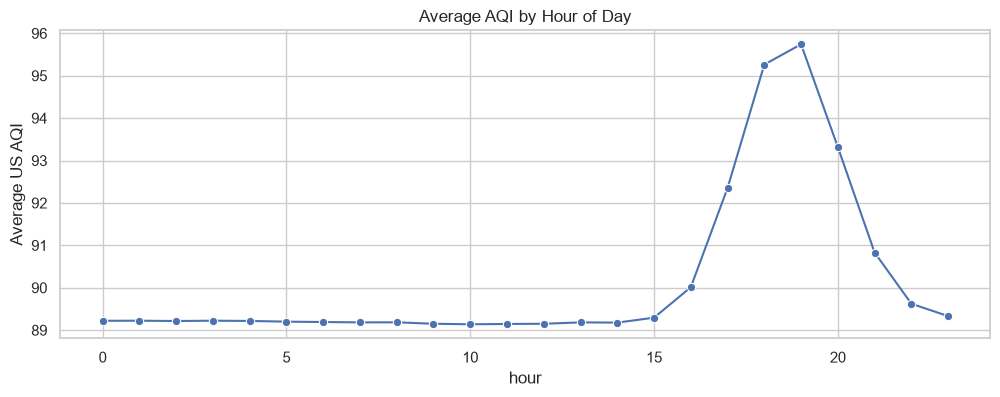

In [26]:
fig, ax = plt.subplots(figsize=(12, 4))
sns.lineplot(data=eda, x="hour", y="us_aqi", estimator="mean", errorbar=None, marker="o", ax=ax)
ax.set_title("Average AQI by Hour of Day")
ax.set_ylabel("Average US AQI");

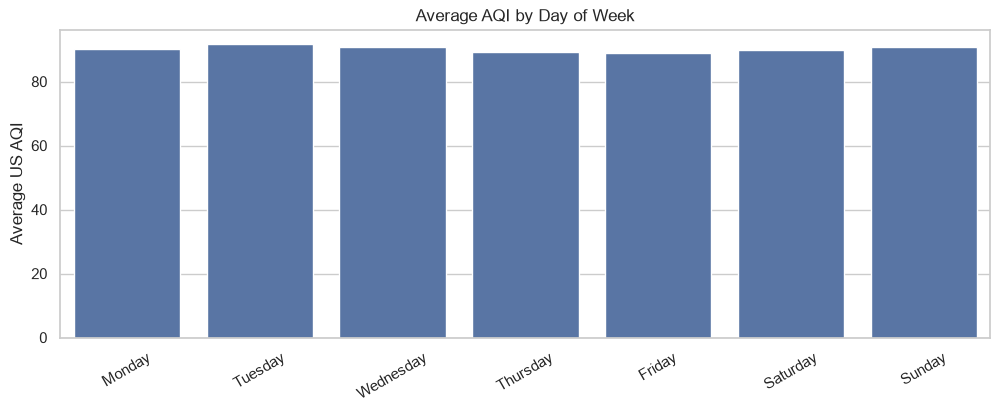

In [27]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

fig, ax = plt.subplots(figsize=(12, 4))
sns.barplot(data=eda, x="day_of_week", y="us_aqi", order=weekday_order, errorbar=None, ax=ax)
ax.set_title("Average AQI by Day of Week")
ax.set_xlabel("")
ax.set_ylabel("Average US AQI")
plt.xticks(rotation=30);

## Looking for Correlations

In [28]:
corr_matrix = eda.select_dtypes(include="number").corr()
corr_matrix["us_aqi"].sort_values(ascending=False)

us_aqi                  1.000000
aqi_rolling_6h          0.960102
pm2_5                   0.722102
sulphur_dioxide         0.507678
pressure_msl            0.443289
carbon_monoxide         0.438859
nitrogen_dioxide        0.342433
pm10                    0.226329
ozone                   0.142105
aqi_change_1h           0.067830
hour                    0.043206
month                   0.006224
precipitation          -0.043851
wind_direction_10m     -0.270808
relative_humidity_2m   -0.332178
temperature_2m         -0.348815
wind_speed_10m         -0.404896
Name: us_aqi, dtype: float64

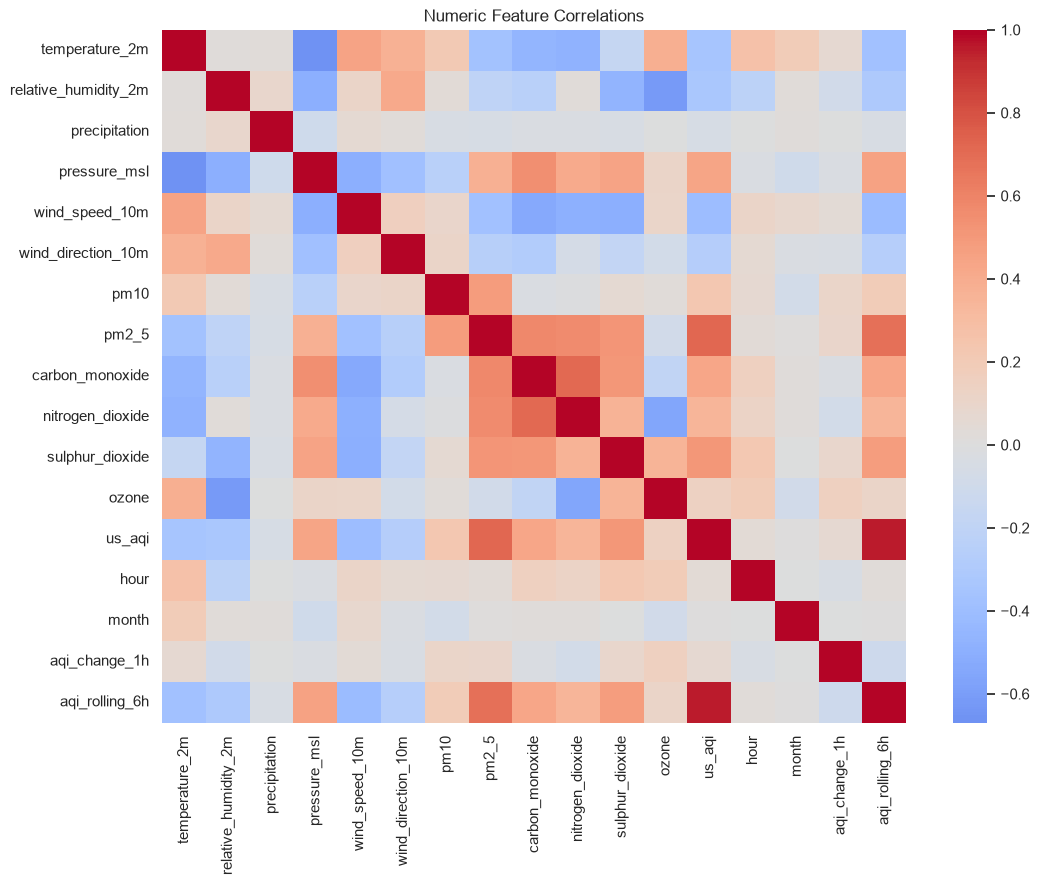

In [29]:
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Numeric Feature Correlations");

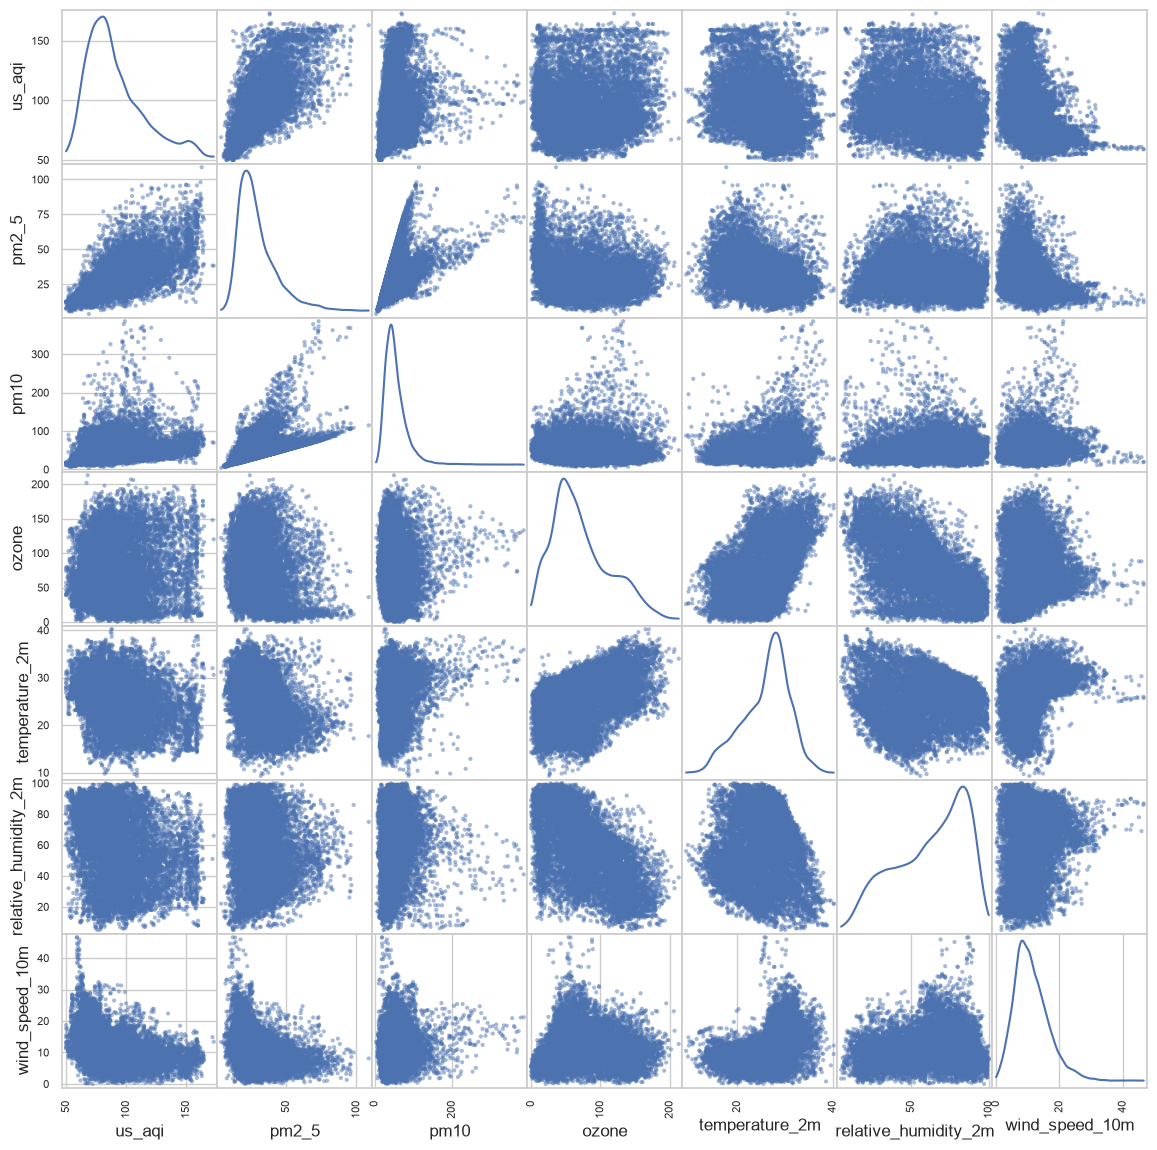

In [30]:
attributes = ["us_aqi", "pm2_5", "pm10", "ozone", "temperature_2m", "relative_humidity_2m", "wind_speed_10m"]
pd.plotting.scatter_matrix(eda[attributes], figsize=(14, 14), diagonal="kde");

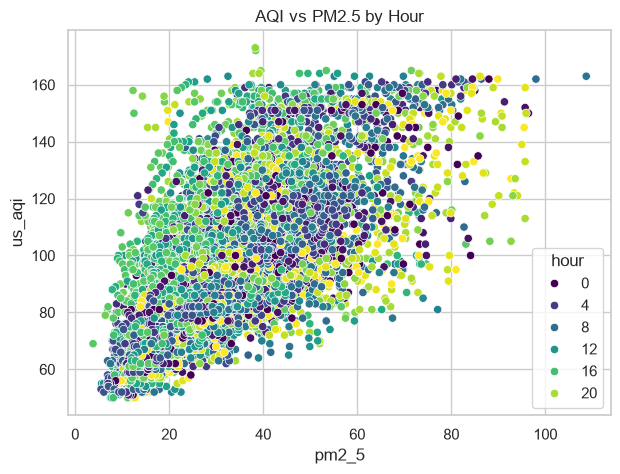

In [31]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=eda, x="pm2_5", y="us_aqi", hue="hour", palette="viridis", ax=ax)
ax.set_title("AQI vs PM2.5 by Hour");

## Notes for Feature Engineering

Good first features to move into `src/aqi_predictor/features/build_features.py` later:

- hour, day of week, and month
- 1-hour AQI change
- 3-hour, 6-hour, and 24-hour rolling pollutant averages
- lagged values for `us_aqi`, `pm2_5`, `pm10`, and weather variables
- hazardous AQI alert flag based on the project threshold